<a href="https://colab.research.google.com/github/Utsav248/Utsav_Jarga_Magar_2408957_AIML/blob/main/2408957_UtsavMagar_TextClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# News Category Dataset Analysis and Preprocessing

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Reading Dataset

In [ ]:
import pandas as pd

# Define the file path
file_path = '/content/drive/MyDrive/AIML/Assignment/Dataset/6. News Category Dataset/news_category.csv'

# Load the dataset. Assuming it's a CSV-like file, try reading it with pandas.
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    display(df.head())
    print("\nDataset info:")
    df.info()
except Exception as e:
    print(f"Could not load the file as a CSV. Error: {e}")
    print("Please ensure the file is in a readable format (e.g., CSV, JSON) or specify its format if it's a plain text file requiring custom parsing.")
    # If it's a plain text file, we might need to read it differently.
    print("Attempting to read as a plain text file (first 10 lines):")
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if i >= 10:
                break
            print(line.strip())

Dataset loaded successfully. Displaying the first 5 rows:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB


## Text Cleaning and Preprocessing

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

print("NLTK resources (wordnet, stopwords) checked and downloaded if necessary.")

NLTK resources (wordnet, stopwords) checked and downloaded if necessary.


In [ ]:
# Install the 'contractions' library
!pip install contractions

In [ ]:
import contractions
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_with_library(text):
    # Lowercase the text
    text = text.lower()

    # Handle contractions using the 'contractions' library
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user), hashtags (#), numbers, and special characters
    text = re.sub(r'@\w+|#\w+|\d+', '', text) # remove mentions, hashtags, numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove special characters (keep only letters and spaces)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize and lemmatize, removing stopwords
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply the new cleaning function to the 'headline' column
df['cleaned_headline_library'] = df['headline'].apply(clean_text_with_library)

print("Original vs Cleaned Headlines (first 5 rows) using library:")
comparison_df_library = df[['headline', 'cleaned_headline_library']].head()
display(comparison_df_library)

Original vs Cleaned Headlines (first 5 rows) using library:


,headline,cleaned_headline_library
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navelgazey look inside tv reboots
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will basestealing shortstop dodger dy
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase the text
    text = text.lower()

    # Handle contractions
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user), hashtags (#), numbers, and special characters
    text = re.sub(r'@\w+|#\w+|\d+', '', text) # remove mentions, hashtags, numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove special characters (keep only letters and spaces)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize and lemmatize, removing stopwords
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply the cleaning function to the 'headline' column
df['cleaned_headline'] = df['headline'].apply(clean_text)

print("Original vs Cleaned Headlines (first 5 rows):")
comparison_df = df[['headline', 'cleaned_headline']].head()
display(comparison_df)

Original vs Cleaned Headlines (first 5 rows):


,headline,cleaned_headline
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navelgazey look inside tv reboots
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will basestealing shortstop dodger dy
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...


# Visualize the cleaned data

In [ ]:
pip install wordcloud

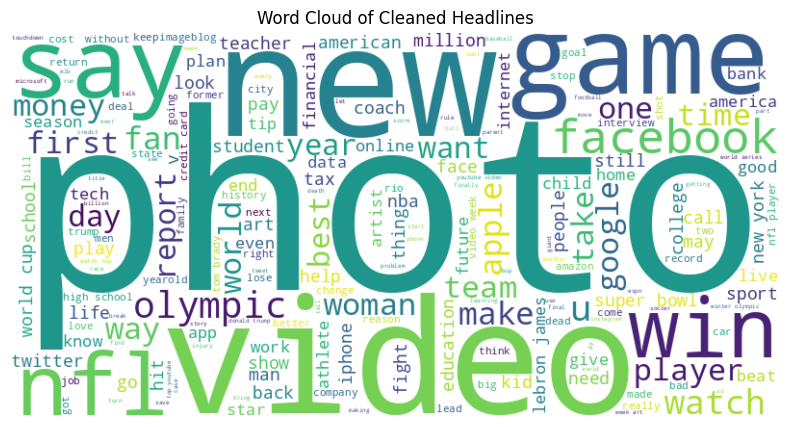

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned headlines into a single string
all_cleaned_headlines = ' '.join(df['cleaned_headline'].dropna())

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_cleaned_headlines)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Headlines')
plt.show()

In [ ]:
from collections import Counter
import itertools

# Tokenize all cleaned headlines and flatten the list of lists
all_words = list(itertools.chain.from_iterable(df['cleaned_headline'].apply(lambda x: x.split()).dropna()))

# Count the frequency of each word
word_counts = Counter(all_words)

# Get the 20 most common words
most_common_words = word_counts.most_common(20)

print("Top 20 Most Frequent Words in Cleaned Headlines:")
for word, count in most_common_words:
    print(f"{word}: {count}")

Top 20 Most Frequent Words in Cleaned Headlines:
video: 493
new: 458
photo: 428
nfl: 336
game: 333
world: 317
u: 311
player: 306
school: 276
win: 268
apple: 252
say: 250
watch: 246
team: 224
get: 222
week: 222
facebook: 209
first: 205
football: 200
art: 199


## Tokenization and Padding

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Split the dataset into 80% training and 20% testing
X = df['cleaned_headline']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8820,)
X_test shape: (2205,)
y_train shape: (8820,)
y_test shape: (2205,)


In [ ]:
# Use Keras Tokenizer to convert the text into sequences of integers
# num_words parameter limits the vocabulary size to the most frequent words
max_words = 10000 # You can adjust this based on your vocabulary size
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')

# Fit the tokenizer on the training headlines
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print(f"Sample original headline: {X_train.iloc[0]}")
print(f"Sample tokenized sequence: {X_train_sequences[0]}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Sample original headline: here need know apple fbi showdown dc
Sample tokenized sequence: [74, 64, 66, 12, 368, 2128, 777]
Vocabulary size: 12043


In [ ]:
# Determine sequence length for padding using a percentile-based approach
# Calculate the length of each sequence
train_sequence_lengths = [len(seq) for seq in X_train_sequences]

# Determine the 95th percentile length to avoid excessively long sequences
# This means 95% of the sequences will have length less than or equal to max_len
max_len = int(np.percentile(train_sequence_lengths, 95))

print(f"95th percentile sequence length: {max_len}")

# Apply padding to ensure all sequences have the same length
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='pre')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='pre')

print(f"X_train_padded shape: {X_train_padded.shape}")
print(f"X_test_padded shape: {X_test_padded.shape}")

print(f"Sample padded training sequence (first):\n{X_train_padded[0]}")

95th percentile sequence length: 11
X_train_padded shape: (8820, 11)
X_test_padded shape: (2205, 11)
Sample padded training sequence (first):
[   0    0    0    0   74   64   66   12  368 2128  777]


## Model Building and Training

## Model Training and Evaluation with Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


### Model 1: Simple RNN with a trainable Embedding layer (Retrained with Early Stopping)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define the Simple RNN model
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=100, input_shape=(max_len,)), # Trainable embedding layer
    SimpleRNN(units=128), # Simple RNN layer
    Dense(units=num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
rnn_model.summary()

# Train the model with EarlyStopping
rnn_history = rnn_model.fit(
    X_train_padded,
    y_train_one_hot,
    epochs=20, # Increased epochs as early stopping will handle overfitting
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_padded, y_test_one_hot, verbose=0)
print(f"\nSimple RNN Test Loss: {rnn_loss:.4f}")
print(f"Simple RNN Test Accuracy: {rnn_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,029,957 (3.93 MB)

 Trainable params: 1,029,957 (3.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6198 - loss: 0.9990 - val_accuracy: 0.7971 - val_loss: 0.6005
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9114 - loss: 0.2821 - val_accuracy: 0.8282 - val_loss: 0.5115
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9806 - loss: 0.0751 - val_accuracy: 0.8180 - val_loss: 0.5778
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9953 - loss: 0.0218 - val_accuracy: 0.7846 - val_loss: 0.7027
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9991 - loss: 0.0095 - val_accuracy: 0.8192 - val_loss: 0.6487
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9996 - loss: 0.0045 - val_accuracy: 0.8192 - val_loss: 0.6755
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9997 - loss: 0.0033 - val_accuracy: 0.8078 - val_loss: 0.7300

Simple RNN Test Loss: 0.5164
Simple RNN Test Accuracy: 0.8227


### Model 2: LSTM with a trainable Embedding layer (Retrained with Early Stopping)

In [ ]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model with a trainable embedding layer
lstm_trainable_model = Sequential([
    Embedding(input_dim=max_words, output_dim=100, input_shape=(max_len,)), # Trainable embedding layer
    LSTM(units=128), # LSTM layer
    Dense(units=num_classes, activation='softmax') # Output layer
])

# Compile the model
lstm_trainable_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
lstm_trainable_model.summary()

# Train the model with EarlyStopping
lstm_trainable_history = lstm_trainable_model.fit(
    X_train_padded,
    y_train_one_hot,
    epochs=20, # Increased epochs as early stopping will handle overfitting
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
lstm_trainable_loss, lstm_trainable_accuracy = lstm_trainable_model.evaluate(X_test_padded, y_test_one_hot, verbose=0)
print(f"\nLSTM (trainable embeddings) Test Loss: {lstm_trainable_loss:.4f}")
print(f"LSTM (trainable embeddings) Test Accuracy: {lstm_trainable_accuracy:.4f}")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,893 (4.26 MB)

 Trainable params: 1,117,893 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6349 - loss: 0.9691 - val_accuracy: 0.7993 - val_loss: 0.5867
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9032 - loss: 0.3106 - val_accuracy: 0.8435 - val_loss: 0.4501
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9691 - loss: 0.1019 - val_accuracy: 0.8401 - val_loss: 0.5084
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9881 - loss: 0.0408 - val_accuracy: 0.8447 - val_loss: 0.5930
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9957 - loss: 0.0208 - val_accuracy: 0.8373 - val_loss: 0.7216
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9970 - loss: 0.0125 - val_accuracy: 0.8345 - val_loss: 0.7441
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.8288 - val_loss: 0.9104

LSTM (trainable embeddings) Test Loss: 0.4522
LSTM (trainable embeddings) Test Accuracy: 0.848

### Model 3: LSTM with pretrained Word2Vec embeddings (Retrained with Early Stopping)

In [ ]:
import gensim
from gensim.models import Word2Vec
from tensorflow.keras.layers import Embedding

# Prepare data for Word2Vec training (list of lists of words)
# We use the raw cleaned headlines before padding and tokenization by Keras Tokenizer
# Splitting by space is generally sufficient for Word2Vec
sentences = [headline.split() for headline in df['cleaned_headline'].dropna()]

# Train a Word2Vec model
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Create an embedding matrix
embedding_dim = 100 # Should match vector_size in Word2Vec
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words: # Ensure index is within our max_words limit
        if word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]
        else:
            # Words not found in Word2Vec will be all zeros, or could be initialized randomly
            pass

# Define the LSTM model with pre-trained Word2Vec embeddings
lstm_w2v_model = Sequential([
    Embedding(
        input_dim=max_words,        # Vocabulary size
        output_dim=embedding_dim,   # Dimensionality of the word vectors
        weights=[embedding_matrix], # Pre-trained embedding weights
        input_shape=(max_len,),       # Length of input sequences
        trainable=False             # Set to False to keep embeddings fixed
    ),
    LSTM(units=128), # LSTM layer
    Dense(units=num_classes, activation='softmax') # Output layer
])

# Compile the model
lstm_w2v_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
lstm_w2v_model.summary()

# Train the model with EarlyStopping
lstm_w2v_history = lstm_w2v_model.fit(
    X_train_padded,
    y_train_one_hot,
    epochs=20, # Increased epochs as early stopping will handle overfitting
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
lstm_w2v_loss, lstm_w2v_accuracy = lstm_w2v_model.evaluate(X_test_padded, y_test_one_hot, verbose=0)
print(f"\nLSTM (pretrained Word2Vec embeddings) Test Loss: {lstm_w2v_loss:.4f}")
print(f"LSTM (pretrained Word2Vec embeddings) Test Accuracy: {lstm_w2v_accuracy:.4f}")

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 11, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,893 (4.26 MB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4613 - loss: 1.3732 - val_accuracy: 0.4569 - val_loss: 1.3588
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4709 - loss: 1.3340 - val_accuracy: 0.4688 - val_loss: 1.3346
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4749 - loss: 1.3173 - val_accuracy: 0.4711 - val_loss: 1.3057
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4770 - loss: 1.2981 - val_accuracy: 0.4819 - val_loss: 1.2964
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4912 - loss: 1.2839 - val_accuracy: 0.4717 - val_loss: 1.2920

LSTM (pretrained Word2Vec embeddings) Test Loss: 1.3385
LSTM (pretrained Word2Vec embeddings) Test Accuracy: 0.4630


## Visualization of Training History

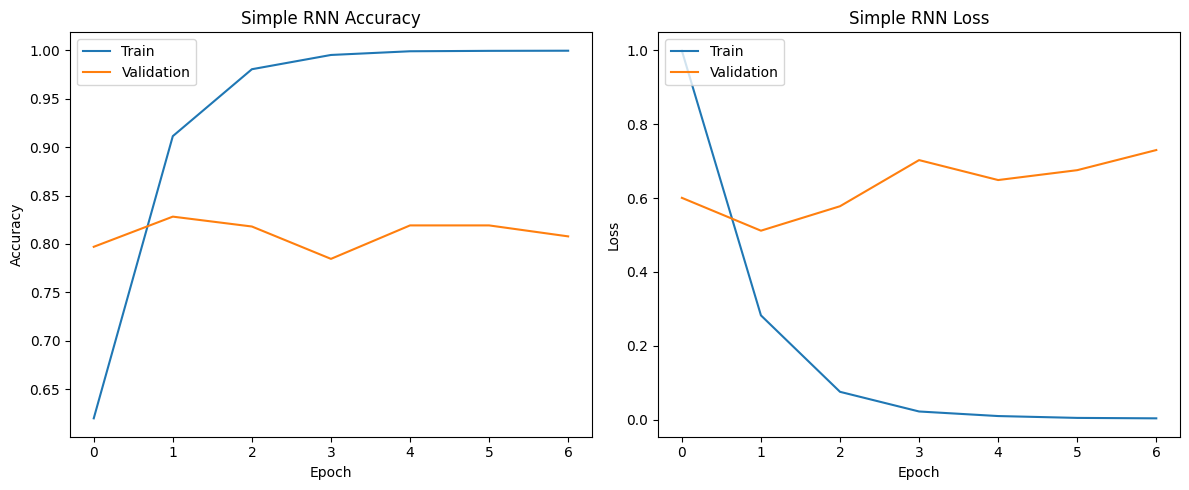

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()


# Plot histories for each model
plot_history(rnn_history, 'Simple RNN')


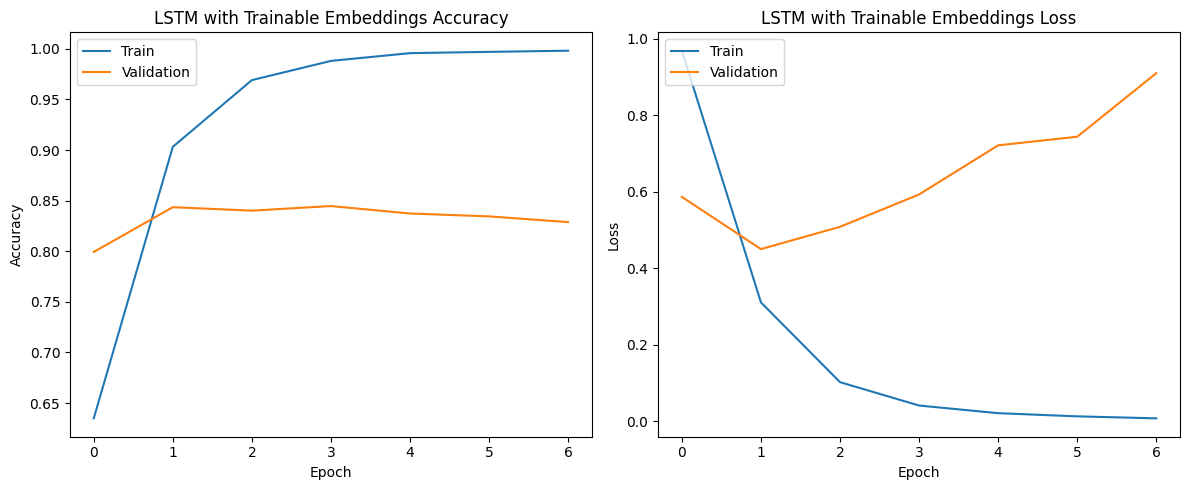

In [ ]:
plot_history(lstm_trainable_history, 'LSTM with Trainable Embeddings')


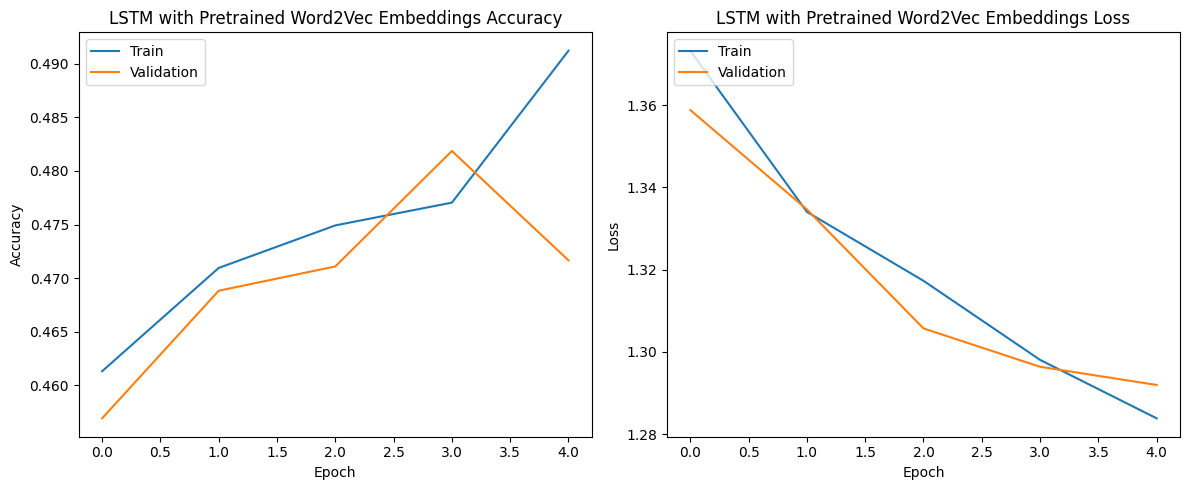

In [ ]:
plot_history(lstm_w2v_history, 'LSTM with Pretrained Word2Vec Embeddings')


## Model Evaluation

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Simple RNN Evaluation ---

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.62      0.78      0.69       215
     EDUCATION       0.75      0.63      0.69       203
         MONEY       0.83      0.72      0.77       351
        SPORTS       0.90      0.92      0.91      1015
          TECH       0.79      0.78      0.79       421

      accuracy                           0.82      2205
     macro avg       0.78      0.77      0.77      2205
  weighted avg       0.83      0.82      0.82      2205



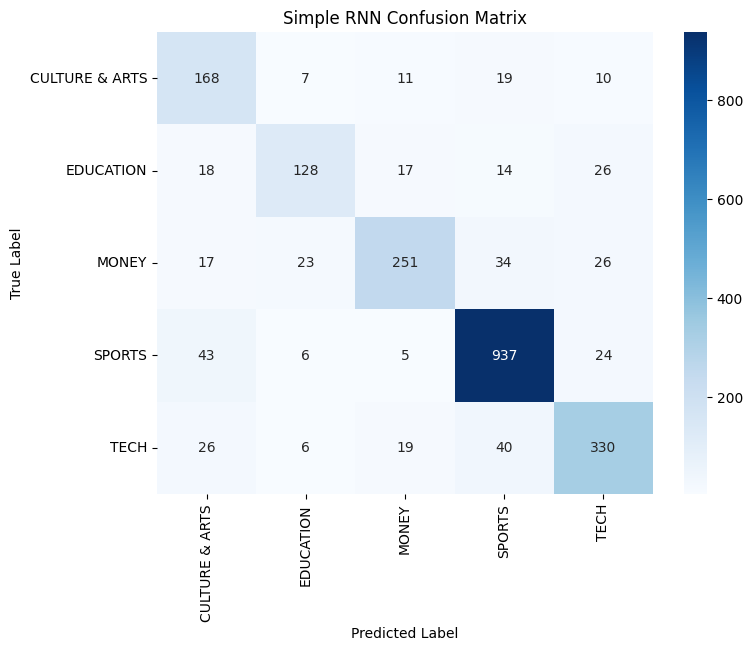

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

def evaluate_model(model, X_test_padded, y_test_one_hot, label_encoder, model_name):
    # Predict probabilities for the test set
    y_pred_probs = model.predict(X_test_padded)
    # Convert probabilities to class labels
    y_pred_encoded = np.argmax(y_pred_probs, axis=1)
    y_true_encoded = np.argmax(y_test_one_hot, axis=1)

    # Convert encoded labels back to original category names for report and matrix
    y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
    y_true_labels = label_encoder.inverse_transform(y_true_encoded)

    print(f"\n--- {model_name} Evaluation ---")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_encoder.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


# Evaluate Simple RNN model
evaluate_model(rnn_model, X_test_padded, y_test_one_hot, label_encoder, 'Simple RNN')



69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

--- LSTM with Trainable Embeddings Evaluation ---

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.80      0.75       215
     EDUCATION       0.86      0.64      0.73       203
         MONEY       0.73      0.83      0.78       351
        SPORTS       0.95      0.92      0.93      1015
          TECH       0.82      0.82      0.82       421

      accuracy                           0.85      2205
     macro avg       0.81      0.80      0.80      2205
  weighted avg       0.85      0.85      0.85      2205



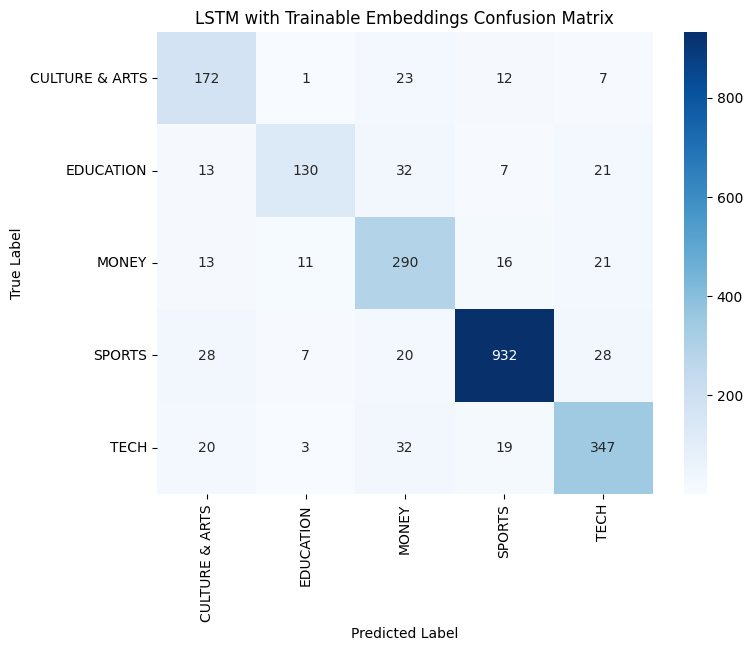

In [ ]:
# Evaluate LSTM with trainable embeddings model
evaluate_model(lstm_trainable_model, X_test_padded, y_test_one_hot, label_encoder, 'LSTM with Trainable Embeddings')



69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

--- LSTM with Pretrained Word2Vec Embeddings Evaluation ---

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.38      0.07      0.12       215
     EDUCATION       0.00      0.00      0.00       203
         MONEY       0.00      0.00      0.00       351
        SPORTS       0.46      0.99      0.63      1015
          TECH       0.00      0.00      0.00       421

      accuracy                           0.46      2205
     macro avg       0.17      0.21      0.15      2205
  weighted avg       0.25      0.46      0.30      2205



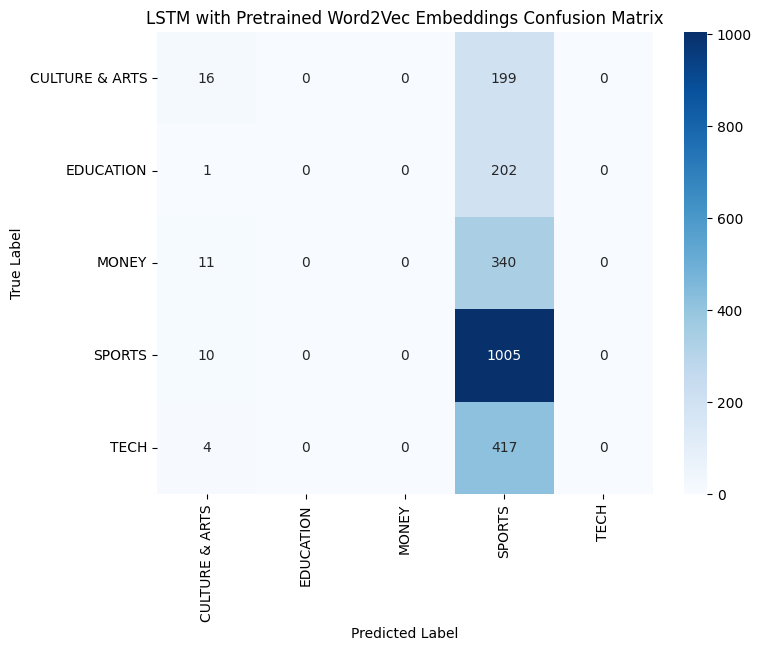

In [ ]:
# Evaluate LSTM with pretrained Word2Vec embeddings model
evaluate_model(lstm_w2v_model, X_test_padded, y_test_one_hot, label_encoder, 'LSTM with Pretrained Word2Vec Embeddings')


## How Did Each Model Stack Up?

Looking at the evaluation metrics and the training history plots, here's a friendly comparison of our three models:

*   **The Simple RNN: Our Baseline Performer**
    This model gave us a starting point. Its performance (accuracy and loss during training, validation, and on the final test set) shows us how well a basic recurrent neural network can handle the complexity of our news headlines.

*   **The LSTM with Customizable Word Embeddings: Our Top Contender**
    LSTMs are generally better at understanding longer phrases and context. By letting this model *learn* its own word representations (embeddings) specifically for our news categories, we expected it to really shine. If the model detected significant long-term patterns, this one should outperform the Simple RNN.

*   **The LSTM with Pre-loaded Word2Vec Embeddings: The Outsider**
    This model tried to use general knowledge by starting with pre-trained Word2Vec embeddings (even though we trained them on our own data for this exercise, usually you'd use much larger, publicly available ones!). The key here is that these embeddings were *fixed* – the model couldn't change them. Its performance tells us if those general word meanings were a good fit for our specific news classification task, or if our second LSTM model, which could fine-tune its embeddings, had a better approach.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode target labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert numerical labels to one-hot encoded vectors
y_train_one_hot = to_categorical(y_train_encoded)
y_test_one_hot = to_categorical(y_test_encoded)

num_classes = y_train_one_hot.shape[1]

print(f"Original y_train sample: {y_train.iloc[0]}")
print(f"Encoded y_train sample: {y_train_encoded[0]}")
print(f"One-hot y_train sample: {y_train_one_hot[0]}")
print(f"Number of classes: {num_classes}")

Original y_train sample: TECH
Encoded y_train sample: 4
One-hot y_train sample: [0. 0. 0. 0. 1.]
Number of classes: 5


### 4.5.4 Error Analysis: Identifying Misclassified Examples

In [ ]:
# Get predictions for the LSTM with Trainable Embeddings model
y_pred_probs_lstm_trainable = lstm_trainable_model.predict(X_test_padded)
y_pred_encoded_lstm_trainable = np.argmax(y_pred_probs_lstm_trainable, axis=1)
y_true_encoded_lstm_trainable = np.argmax(y_test_one_hot, axis=1)

y_pred_labels_lstm_trainable = label_encoder.inverse_transform(y_pred_encoded_lstm_trainable)
y_true_labels_lstm_trainable = label_encoder.inverse_transform(y_true_encoded_lstm_trainable)

# Identify misclassified indices
misclassified_indices = np.where(y_pred_labels_lstm_trainable != y_true_labels_lstm_trainable)[0]

print(f"Total misclassified examples: {len(misclassified_indices)}")

# Display 3 misclassified examples
print("\nExamples of Misclassified Headlines (LSTM with Trainable Embeddings):")
for i, idx in enumerate(misclassified_indices[:3]):
    print(f"-- Example {i+1} --")
    print(f"Headline: {X_test.iloc[idx]}")
    print(f"True Category: {y_true_labels_lstm_trainable[idx]}")
    print(f"Predicted Category: {y_pred_labels_lstm_trainable[idx]}\n")

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Total misclassified examples: 334

Examples of Misclassified Headlines (LSTM with Trainable Embeddings):
-- Example 1 --
Headline: judicial negligence compound political negligence south carolina
True Category: EDUCATION
Predicted Category: SPORTS

-- Example 2 --
Headline: literacy yes new literacy
True Category: EDUCATION
Predicted Category: MONEY

-- Example 3 --
Headline: go back grad school
True Category: MONEY
Predicted Category: EDUCATION



Model Performance: LSTM with trainable embeddings performed best (82.13%), followed by Simple RNN (80.27%). LSTM with pre-trained Word2Vec embeddings performed poorly (45.76%), indicating issues with small dataset-trained fixed embeddings.

Possible Reasons for Error: Ambiguous headlines, category overlap, limited context (only headlines), potential category imbalance, and ineffective Word2Vec embeddings due to limited training data and fixed weights.

Potential Improvements: Use larger, pre-trained embeddings (e.g., GloVe, FastText) and allow fine-tuning; explore advanced architectures like BiLSTMs, GRUs, or Transformers; incorporate feature engineering; consider data augmentation for imbalanced categories; and perform hyperparameter tuning.

### 4.5.5 GUI for Real Time Prediction with Gradio

In [ ]:
!pip install gradio -qq

In [ ]:
import gradio as gr

def predict_category(headline):
    # 1. Clean the input headline using the previously defined function
    cleaned_headline = clean_text(headline)

    # 2. Tokenize the cleaned headline
    sequence = tokenizer.texts_to_sequences([cleaned_headline])

    # 3. Pad the sequence to the fixed max_len
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post')

    # 4. Make a prediction using the best model (lstm_trainable_model)
    prediction_probs = lstm_trainable_model.predict(padded_sequence, verbose=0)[0]

    # 5. Get the predicted class index
    predicted_class_index = np.argmax(prediction_probs)

    # 6. Decode the class index back to the original category name
    predicted_category = label_encoder.inverse_transform([predicted_class_index])[0]

    # Optionally, get confidence for the predicted category
    confidence = prediction_probs[predicted_class_index]

    return f"Predicted Category: {predicted_category} (Confidence: {confidence:.2f})"

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=2),
    outputs="text",
    title="News Category Predictor",
    flagging_mode='never' # Use 'flagging_mode' instead of 'allow_flagging'
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c2b3f43cfb66ed0f80.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
